# Load Results

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import torch
from sklearn.metrics import roc_curve, auc, precision_recall_curve, average_precision_score
import cvxpy as cp
import os
from matplotlib.patches import Patch
import fair_model_loan
import baseline_model_loan
from load_data import load_sba_splits
from configs import loan_xp_params

pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', None)

/Users/davidtroxell/miniconda3/envs/sg2im/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
size = "small"
results = pd.read_csv(f"./results/test_loss_log_{size}.csv")

# Boxplots


Projection:
  AUC  - Mean: -1.38%, Median: -1.24%
  AP   - Mean: -3.07%, Median: -3.26%

Strict Penalty:
  AUC  - Mean: -43.19%, Median: -43.87%
  AP   - Mean: -56.99%, Median: -58.44%


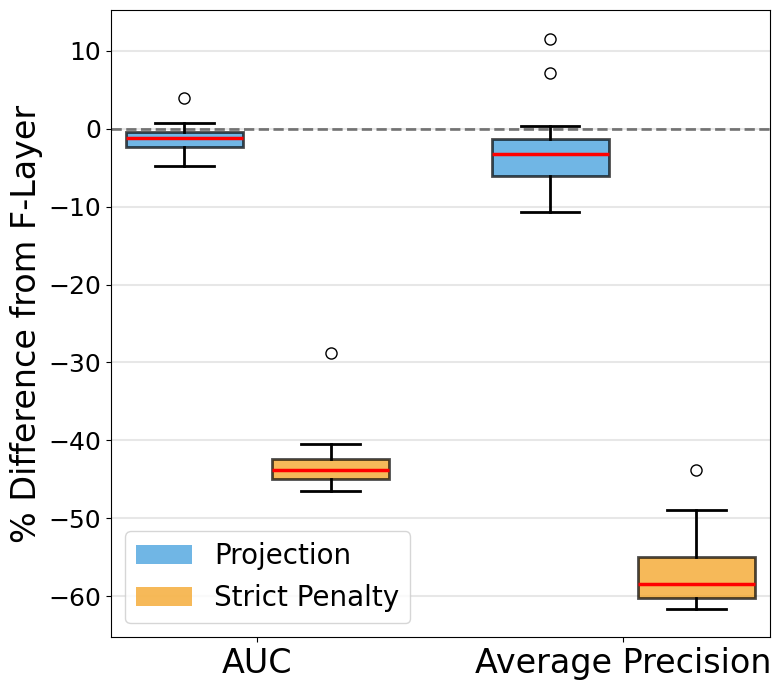

In [3]:
FIGSIZE = (8, 7)

fig, ax = plt.subplots(1, 1, figsize=FIGSIZE)

results = pd.read_csv(f'./results/test_loss_log_{size}.csv')

# Separate fair models from comparison models
fair_models = results[results['model_type'] == 'fair_loan'].copy()
comparison_models = results[results['model_type'].isin(['baseline_loan', 'strict_penalty_loan'])].copy()
merged = comparison_models.merge(
    fair_models[['data_seed', 'ap_fair', 'auc_fair']], 
    on='data_seed', 
    suffixes=('_comp', '_fair')
)

# get relative diffs
merged['ap_fair_rel_diff'] = 100 * (merged['ap_fair_comp'] - merged['ap_fair_fair']) / merged['ap_fair_fair']
merged['auc_fair_rel_diff'] = 100 * (merged['auc_fair_comp'] - merged['auc_fair_fair']) / merged['auc_fair_fair']
model_types = ['baseline_loan', 'strict_penalty_loan']
model_labels = ['Projection', 'Strict Penalty']
colors = ['#3498db', '#f39c12']

auc_data = [merged[merged['model_type'] == mt]['auc_fair_rel_diff'].dropna() for mt in model_types]
ap_data = [merged[merged['model_type'] == mt]['ap_fair_rel_diff'].dropna() for mt in model_types]
for mt, label, auc_vals, ap_vals in zip(model_types, model_labels, auc_data, ap_data):
    print(f"\n{label}:")
    print(f"  AUC  - Mean: {auc_vals.mean():.2f}%, Median: {auc_vals.median():.2f}%")
    print(f"  AP   - Mean: {ap_vals.mean():.2f}%, Median: {ap_vals.median():.2f}%")

#AUC boxplots
positions_auc = [1, 2]
positions_ap = [3.5, 4.5]
bp_auc = ax.boxplot(auc_data, positions=positions_auc, widths=0.8, patch_artist=True,
                     boxprops=dict(facecolor='white', linewidth=2),
                     medianprops=dict(color='red', linewidth=2.5),
                     whiskerprops=dict(linewidth=2),
                     capprops=dict(linewidth=2),
                     flierprops=dict(markersize=8))

#AP boxplots
bp_ap = ax.boxplot(ap_data, positions=positions_ap, widths=0.8, patch_artist=True,
                    boxprops=dict(facecolor='white', linewidth=2),
                    medianprops=dict(color='red', linewidth=2.5),
                    whiskerprops=dict(linewidth=2),
                    capprops=dict(linewidth=2),
                    flierprops=dict(markersize=8))
for i, (patch_auc, patch_ap, color) in enumerate(zip(bp_auc['boxes'], bp_ap['boxes'], colors)):
    patch_auc.set_facecolor(color)
    patch_auc.set_alpha(0.7)
    patch_ap.set_facecolor(color)
    patch_ap.set_alpha(0.7)

ax.set_xticks([1.5, 4])
ax.set_xticklabels(['AUC', 'Average Precision'], fontsize=24)
ax.tick_params(axis='y', labelsize=18)
ax.axhline(y=0, color='black', linestyle='--', alpha=0.5, linewidth=2)
ax.set_ylabel('% Difference from F-Layer', fontsize=24)
ax.grid(True, alpha=0.3, axis='y', linewidth=1.5)

legend_elements = [Patch(facecolor=color, alpha=0.7, label=label) 
                   for color, label in zip(colors, model_labels)]
ax.legend(handles=legend_elements, loc='best', fontsize=20)

plt.tight_layout()
plt.savefig(f'./results/boxplot_{size}.png', dpi=300, bbox_inches='tight')
plt.show()
plt.close()

# ROC Curves

In [ ]:
fig, ax = plt.subplots(1, 1, figsize=FIGSIZE)

def fair_projection_for_baseline(raw_logits, attr1_indicator, attr2_indicator):
    '''
    Helper func that performs Projection for loan xp
    '''
    n = len(raw_logits)
    yhat = cp.Variable(n)
    
    attr1_0_mask = (attr1_indicator == 0)
    attr1_1_mask = (attr1_indicator == 1)
    n_attr1_0 = attr1_0_mask.sum()
    n_attr1_1 = attr1_1_mask.sum()
    
    constr = []
    slack = loan_xp_params.get_slack()
    
    if n_attr1_0 > 0 and n_attr1_1 > 0:
        sum_attr1_0 = cp.sum(cp.multiply(yhat, attr1_0_mask))
        sum_attr1_1 = cp.sum(cp.multiply(yhat, attr1_1_mask))
        constr += [sum_attr1_0 / n_attr1_0 - sum_attr1_1 / n_attr1_1 <= slack]
        constr += [-(sum_attr1_0 / n_attr1_0 - sum_attr1_1 / n_attr1_1) <= slack]
    
    attr2_0_mask = (attr2_indicator == 0)
    attr2_1_mask = (attr2_indicator == 1)
    n_attr2_0 = attr2_0_mask.sum()
    n_attr2_1 = attr2_1_mask.sum()
    
    if n_attr2_0 > 0 and n_attr2_1 > 0:
        sum_attr2_0 = cp.sum(cp.multiply(yhat, attr2_0_mask))
        sum_attr2_1 = cp.sum(cp.multiply(yhat, attr2_1_mask))
        constr += [sum_attr2_0 / n_attr2_0 - sum_attr2_1 / n_attr2_1 <= slack]
        constr += [-(sum_attr2_0 / n_attr2_0 - sum_attr2_1 / n_attr2_1) <= slack]
    
    objective = cp.Minimize(cp.sum_squares(yhat - raw_logits))
    problem = cp.Problem(objective, constr)
    problem.solve(solver=cp.SCS, eps=1e-6, max_iters=80000, verbose=False)
    
    return yhat.value, problem.status

# Plot ROC curves

roc_model_types = ['fair', 'baseline', 'strict_penalty']
roc_model_labels = ['F-Layer', 'Projection', 'Strict Penalty']
roc_colors = [ "black",'#3498db', '#f39c12']

num_seeds = 25
skipped=0
for model_type, label, color in zip(roc_model_types, roc_model_labels, roc_colors):
    tprs_roc = []
    aucs_roc = []
    mean_fpr = np.linspace(0, 1, 100)
    
    for data_seed in range(num_seeds):
        for attempts in range(100):
            try:
                X_train, y_train, X_val, y_val, X_test, y_test = load_sba_splits(data_seed=data_seed)
                break
            except:
                pass
            
        X_test = X_test.drop(columns=['xx', 'UrbanRural'])
        
        X_test_tensor = torch.tensor(X_test.values, dtype=torch.float32)
        y_test_array = y_test.values if hasattr(y_test, 'values') else np.array(y_test)
        
        p_pos = (y_train.sum() / len(y_train)).item()
        num_cols = X_train.shape[1] - 2
        
        model_path = f"./loan_models/{model_type}_{data_seed}.pth"
        if not os.path.exists(model_path):
            continue
        
        if model_type == "fair":
            model = fair_model_loan.FairModelcvxpy(p_pos=p_pos, num_cols=num_cols, size=size)
        else:
            model = baseline_model_loan.BaselineRegressionModel(p_pos, num_cols=num_cols, size=size)
        
        model.load_state_dict(torch.load(model_path))
        model.eval()
        
        with torch.no_grad():
            logits = model(X_test_tensor).squeeze().cpu().numpy()
            
            if model_type == "baseline":
                attr1 = X_test_tensor[:, -2].cpu().numpy()
                attr2 = X_test_tensor[:, -1].cpu().numpy()
                fair_logits, _ = fair_projection_for_baseline(logits, attr1, attr2)
                probs = 1 / (1 + np.exp(-fair_logits))
            else:
                probs = 1 / (1 + np.exp(-logits))
        
        fpr, tpr, _ = roc_curve(y_test_array, probs)
        roc_auc = auc(fpr, tpr)
        interp_tpr = np.interp(mean_fpr, fpr, tpr)
        interp_tpr[0] = 0.0
        tprs_roc.append(interp_tpr)
        aucs_roc.append(roc_auc)

            
    
    if len(tprs_roc) > 0:
        mean_tpr = np.mean(tprs_roc, axis=0)
        mean_tpr[-1] = 1.0
        std_tpr = np.std(tprs_roc, axis=0)
        ax.plot(mean_fpr, mean_tpr, color=color, lw=3, label=label)

        tprs_upper = np.minimum(mean_tpr + std_tpr, 1)
        tprs_lower = np.maximum(mean_tpr - std_tpr, 0)
        ax.fill_between(mean_fpr, tprs_lower, tprs_upper, color=color, alpha=0.2)

ax.plot([0, 1], [0, 1], 'k--', lw=2)
ax.set_xlim([0.0, 1.0])
ax.set_ylim([0.0, 1.05])
ax.set_xlabel('False Positive Rate', fontsize=24)
ax.set_ylabel('True Positive Rate', fontsize=24)
ax.legend(loc="lower right", fontsize=20)
ax.grid(alpha=0.3, linewidth=2.5)
ax.tick_params(axis='both', labelsize=20)

plt.tight_layout()
plt.savefig(f'./results/roc_curves_{size}.png', dpi=300, bbox_inches='tight')
plt.show()
plt.close()

print(skipped)

[info] Auto-detected file_path='SBAcase.11.13.17.csv'
Index(['Selected', 'LoanNr_ChkDgt', 'Name', 'City', 'State', 'Zip', 'Bank',
       'BankState', 'NAICS', 'ApprovalDate', 'ApprovalFY', 'Term', 'NoEmp',
       'NewExist', 'CreateJob', 'RetainedJob', 'FranchiseCode', 'UrbanRural',
       'RevLineCr', 'LowDoc', 'ChgOffDate', 'DisbursementDate',
       'DisbursementGross', 'BalanceGross', 'MIS_Status', 'ChgOffPrinGr',
       'GrAppv', 'SBA_Appv', 'New', 'RealEstate', 'Portion', 'Recession',
       'daysterm', 'xx', 'Default'],
      dtype='object')
Number of unique NAICS values: 24
Train: (1428, 110) Val: (253, 110) Test: (421, 110)
Last 2 features (protected): ['Protected_NewExist', 'Protected_Urban']

Protected_NewExist statistics:
  Train: {0: 1208, 1: 220}
  Val: {0: 222, 1: 31}
  Test: {0: 348, 1: 73}

Protected_Urban statistics:
  Train: {1: 1186, 0: 242}
  Val: {1: 196, 0: 57}
  Test: {1: 360, 0: 61}
[info] Auto-detected file_path='SBAcase.11.13.17.csv'
Index(['Selected', 'LoanN

# PR Curves

In [ ]:
fig, ax = plt.subplots(1, 1, figsize=FIGSIZE)
skipped=0
for model_type, label, color in zip(roc_model_types, roc_model_labels, roc_colors):
    precisions_pr = []
    aps_pr = []
    mean_recall = np.linspace(0, 1, 100)
    
    for data_seed in range(num_seeds):
        for attempts in range(100):
            try:
                X_train, y_train, X_val, y_val, X_test, y_test = load_sba_splits(data_seed=data_seed)
                break
            except:
                pass

        X_train, y_train, X_val, y_val, X_test, y_test = load_sba_splits(data_seed=data_seed)
        X_test = X_test.drop(columns=['xx', 'UrbanRural'])
        
        X_test_tensor = torch.tensor(X_test.values, dtype=torch.float32)
        y_test_array = y_test.values if hasattr(y_test, 'values') else np.array(y_test)
        
        p_pos = (y_train.sum() / len(y_train)).item()
        num_cols = X_train.shape[1] - 2
        
        model_path = f"./loan_models/{model_type}_{data_seed}.pth"
        if not os.path.exists(model_path):
            continue
        
        if model_type == "fair":
            model = fair_model_loan.FairModelcvxpy(p_pos=p_pos, num_cols=num_cols, size=size)
        else:
            model = baseline_model_loan.BaselineRegressionModel(p_pos, num_cols=num_cols, size=size)
        
        model.load_state_dict(torch.load(model_path))
        model.eval()
        
        with torch.no_grad():
            logits = model(X_test_tensor).squeeze().cpu().numpy()
            
            if model_type == "baseline":
                attr1 = X_test_tensor[:, -2].cpu().numpy()
                attr2 = X_test_tensor[:, -1].cpu().numpy()
                fair_logits, _ = fair_projection_for_baseline(logits, attr1, attr2)
                probs = 1 / (1 + np.exp(-fair_logits))
            else:
                probs = 1 / (1 + np.exp(-logits))
        
        precision, recall, _ = precision_recall_curve(y_test_array, probs)
        ap = average_precision_score(y_test_array, probs)
        precision_rev = precision[::-1]
        recall_rev = recall[::-1]
        interp_precision = np.interp(mean_recall, recall_rev, precision_rev)
        precisions_pr.append(interp_precision)
        aps_pr.append(ap)
    
    if len(precisions_pr) > 0:
        mean_precision = np.mean(precisions_pr, axis=0)
        std_precision = np.std(precisions_pr, axis=0)
        
        # Plot mean line
        ax.plot(mean_recall, mean_precision, color=color, lw=3, label=label)
        
        # Add shaded region for ±1 standard deviation
        precision_upper = np.minimum(mean_precision + std_precision, 1)
        precision_lower = np.maximum(mean_precision - std_precision, 0)
        ax.fill_between(mean_recall, precision_lower, precision_upper, color=color, alpha=0.2)

# Format PR plot
ax.set_xlim([0.0, 1.0])
ax.set_ylim([0.0, 1.05])
ax.set_xlabel('Recall', fontsize=24)
ax.set_ylabel('Precision', fontsize=24)
ax.legend(loc="lower left", fontsize=20)
ax.grid(alpha=0.3, linewidth=2.5)
ax.tick_params(axis='both', labelsize=20)

plt.tight_layout()
plt.savefig(f'./results/pr_curves_{size}.png', dpi=300, bbox_inches='tight')
plt.show()
plt.close()
print(skipped)